In [1]:
## BEGIN
import numpy as np
import scipy.linalg as la
import scipy.stats as sst
from functools import reduce

import matplotlib 
import matplotlib.pyplot as plt
from matplotlib import rc

cmap = matplotlib.colormaps["viridis"]
plt.style.use("default")

#plt.rcParams['figure.dpi'] = 300
plt.rcParams.update({'font.size': 20})# 

#rc('text', usetex=True)
rc("axes", linewidth= 1.1)

## Computing transition rates

We look at a brickwall circuit whose gates are of the form 
\begin{equation*}
u = \begin{pmatrix}
1 & 0 \\
0 & \text{Haar}
\end{pmatrix}
\end{equation*}
We look at the folded 2-replica circuit, in which every site is of dimension $q^4$.

The averaged gate $\Phi := \mathbb{E}[(u\otimes (u^{-1})^{*})^{\otimes 2}]$ is a projector onto a space of 7 elements $|ii \rangle $:
\begin{equation*}
\Phi = \sum_{j,j'}M_{jj'}|jj\rangle\rangle \langle \langle j'j'|
\end{equation*}

In order to compute the evolution of the system, we need to compute the Gram matrix elements $G(q) = \langle \langle i|j\rangle\rangle$, as well as the matrix elements $M(q) = \langle \langle ii|jj\rangle\rangle^{-1} = G(q^2)^{-1}$

After one time step, the evolution is then entirely determined by the computation of the coefficients $r_{i\leftarrow k,k'}$ found in
\begin{equation*}
\Phi |k,k'\rangle \rangle = \sum_i r_{i \leftarrow k,k'} |ii \rangle \rangle
\end{equation*}

These coefficients are given by 
\begin{equation*}
r_{i \leftarrow k,k'} = \sum_j M_{ij} G_{jk} G_{j,k'}
\end{equation*}

In [2]:
#compute the Gram matrix
def Gram(q):
    return np.array([[1,1,1,1,1,1,1],[1,q**2,q,q,q,1,1],[1,q,q,1,1,1,1],[1,q,1,q,1,1,1],[1,q,1,1,q**2,q,q],[1,1,1,1,q,q,1],[1,1,1,1,q,1,q]])

#compute r_{i<-k,k'}
def trans(i,k1,k2,q):
    G_q = Gram(q)
    M = la.inv(Gram(q**2))
    return np.sum([M[i,j] * G_q[j,k1] * G_q[j,k2] for j in range(7)])

#array of dimension 7*7*7 containing all the r_{i<-k,k'}
def trans_rates(q):
    return(np.array([[[trans(i,k1,k2,q) for k2 in range(7)] for k1 in range(7)] for i in range(7)]))


## Evolving the system

We are interested in the evolution of a 1d chain where the initial state of every site is an element of the basis of $Im(\Phi)$.

Most of the time we want to compute the evolution of systems of the form $| l \hspace{0.5mm} ... \hspace{0.5mm} l \hspace{0.5mm} O \hspace{0.5mm} r \hspace{0.5mm} ... \hspace{0.5mm} r \rangle \rangle $, where $O$ is a 1- or 2-sites operator.

After one step, the operator is projected onto the basis, and we are left we evolving elements of the form $| l\hspace{0.5mm} ... \hspace{0.5mm} l \hspace{0.5mm} k_1 \hspace{0.5mm} k_2 \hspace{0.5mm} r \hspace{0.5mm} ... \hspace{0.5mm} r \rangle \rangle$.

Since $\Phi$ is a projector, we know it leaves $| l l \rangle \rangle$ and $| r r \rangle \rangle$ unchanged. So in practice we only need to compute the evolution of the cone around $| k_2 k_2 \rangle \rangle$.

Generically, we obtain after $t$ time steps a state of the form
\begin{equation*}
|s(t) \rangle \rangle = \sum c_{i_1,...,i_{t+1}} |l \hspace{0.5mm} ... \hspace{0.5mm} l \hspace{0.5mm} i_1 \hspace{0.5mm} i_1 \hspace{0.5mm} ... \hspace{0.5mm} i_{t+1} \hspace{0.5mm} i_{t+1} \hspace{0.5mm} r \hspace{0.5mm} ... \hspace{0.5mm} r \rangle \rangle
\end{equation*}

Our goal is thus to compute for each time step the coefficients $c_{i_1,...i_{t+1}}$, that are stored in a dictionary $C(t)$. The main difficulty comes from the fact that these coefficients can be negative, so we cannot sample $C(t)$ from a Markov evolution.

For $t=0$, we have
\begin{equation*}
c_{i_1,i_2} = \delta_{i_1,k_1} \delta_{i_2,k_2}
\end{equation*}

Evolving the sytem from $t$ to $t+1$ gives:
\begin{align*}
\Phi \otimes ... \otimes \Phi |s(t) \rangle \rangle &= \sum_{i_1,...,i_{t+1}} c_{i_1,...,i_{t+1}} \Phi \otimes ... \otimes \Phi  |l \hspace{0.5mm} ... \hspace{0.5mm} l \hspace{0.5mm} i_1 \hspace{0.5mm} i_1 \hspace{0.5mm} ... \hspace{0.5mm} i_{t+1} \hspace{0.5mm} i_{t+1} \hspace{0.5mm} r \hspace{0.5mm} ... \hspace{0.5mm} r \rangle \rangle\\
&= \sum_{i_1,...,i_{t+1}} c_{i_1,...,i_{t+1}} |l...l \rangle \rangle \Phi |l i_1 \rangle \rangle ... \Phi |i_{t+1} r \rangle \rangle |r...r \rangle \rangle\\
&= \sum_{i_1,...,i_{t+1}} c_{i_1,...,i_{t+1}} |l...l \rangle \rangle r_{j_1 \leftarrow l, i_1} |j_1 j_1 \rangle \rangle ... r_{j_{t+2} \leftarrow i_{t+1}, r} | \rangle \rangle |r...r \rangle \rangle\\
&= \sum_{j_1,...,j_{t+2}} c_{j_1,...,j_{t+2}} |l ...l \hspace{0.5mm} j_1 \hspace{0.5mm} j_1 ... j_{t+2} \hspace{0.5mm} j_{t+2} \hspace{0.5mm} r ... r \rangle \rangle
\end{align*}

with 
\begin{equation*}
c_{j_1,...,j_{t+2}} = \sum_{i_1,...,i_{t+1}} c_{i_1,...,i_{t+1}} r_{j_1 \leftarrow l, i_1} ... r_{j_{t+2} \leftarrow i_{t+1}, r}
\end{equation*}

which can be implemented directly using the einsum() function from Numpy.

### Finite-size evolution

The previous algorithm breaks down as soon as the evolution cone reaches the size of the system, and no more $l$ and $r$ coefficients are to be found at the extremities of the chain. This happens at $t=L/2$ steps, with $L$ the size of the system.

From that point on, we need to separate the evolution into even and odd time steps. We index time by $t_2 = t - L/2$.

For $t_2$ odd, the evolution is the same, except that terms with $l$ or $r$ in the previous equation disappear, and the new coefficients have $L/2$ indices. On the contrary, for $t_2$ even, the leftmost and rightmost sites do not evolve, while all the intermediate sites follow the previous scheme, and the new coefficient have $L/2+1$ indices. (Drawing the corresponding diagrams can help understanding these computations.)

\begin{equation*}
c_{j_1,...,j_{L/2}} = \sum_{i_1,...,i_{L/2+1}} c_{i_1,...,i_{L/2+1}} r_{j_1 \leftarrow i_1, i_2} ... r_{j_{L/2} \leftarrow i_{L/2}, i_{L/2+1}}
\end{equation*}

\begin{equation*}
c_{j_1,...,j_{L/2+1}} = \sum_{i_1,...,i_{L/2}} c_{j_1,i_2,...i_{L/2-1},j_{L/2+1}} r_{j_2 \leftarrow j_1, i_2} ... r_{j_{L/2} \leftarrow i_{L/2-1}, j_{L/2+1}}
\end{equation*}

### Finite-size evolution from a given chain

To compute the Page curve, we will need to evolve chains of the form $|l...l \hspace{0.5mm} r...r \rangle \rangle$ where the cut is not at center of the chain. For that, we use an algorithm that can evolve a generical chain $|k_1...k_N \rangle \rangle$ on a finite-size system.

The first coefficients are given by:
\begin{equation*}
c_{i_1...i_L} = \delta_{i_1,k_1}...\delta_{i_L,k_L}
\end{equation*}

while the coefficients at further time steps are given by the same formula as in the previous finite-size evolution.

In [3]:
#evolve a chain where the central config is [k_1,k_2], all the sites on the left are l and the ones on the right are r, for T time steps
#output is a dictionnary of arrays Cs = {t:C_t} where C_t is an array of dimension 7**(t+1) and each coefficient C_t[i_1...i_(t+1)] is the coefficient associated with configuration |l...l i_1...i_(t+1) r...r>>
def C_evol(l,k1,k2,r,T,rates):
    Cs = {}
    Cs[0] = rates[:,k1,k2]
    for t in range(T-1):
        Cs[t+1] = np.einsum(*[Cs[t],np.arange(t+1)] + [rates[:,l,:],[t+1,0]] + [elt for elt2 in [[rates,[t+2+j,j,j+1]] for j in range(t)] for elt in elt2] + [rates[:,:,r],[2*t+2,t]],optimize='greedy')
    return Cs

#evolve in a finite size lattice of length L (L even)
def finite_size_evolve(l,k1,k2,r,T,rates,L):
    Cs = C_evol(l,k1,k2,r,min(L//2,T),rates)
    for t_2 in range(T-L//2):
        if t_2%2==0:
            Cs[t_2+L//2] = np.einsum(*[Cs[t_2+L//2-1],np.arange(L//2)] + [np.identity(7),[L//2,0]] + [elt for elt2 in [[rates,[L//2+1+j,j,j+1]] for j in range(L//2-1)] for elt in elt2] + [np.identity(7),[L,L//2-1]],optimize='greedy')
        else:
            Cs[t_2+L//2] = np.einsum(*[Cs[t_2+L//2-1],np.arange(L//2+1)] + [elt for elt2 in [[rates,[L//2+1+j,j,j+1]] for j in range(L//2)] for elt in elt2],optimize='greedy') 
    return(Cs)

#evolve a finite size-system from a given configuration
def direct_evol(sites,T,rates):
    N = len(sites)
    C = reduce(np.multiply, np.ix_(*[rates[:,sites[2*i],sites[2*i+1]] for i in range(N//2)])) 
    Cs = {0:C}
    for i in range(T):
        if i%2==0:
            Cs[i+1] = np.einsum(*[Cs[i],np.arange(L//2)] + [np.identity(7),[L//2,0]] + [elt for elt2 in [[rates,[L//2+1+j,j,j+1]] for j in range(L//2-1)] for elt in elt2] + [np.identity(7),[L,L//2-1]],optimize='greedy')
        else:
            Cs[i+1] = np.einsum(*[Cs[i],np.arange(L//2+1)] + [elt for elt2 in [[rates,[L//2+1+j,j,j+1]] for j in range(L//2)] for elt in elt2],optimize='greedy')
    return(Cs)

## Computing purity

The second Renyi entropy of a state $\rho$ is defined as
\begin{equation*}
S_2 = - \log \langle \langle \text{SWAP}_A, 1_{\bar{A}} | \rho\otimes \rho \rangle \rangle
\end{equation*}

We want to find $S_2$ when the initial state is $|\psi \rangle = (\sqrt{1-\lambda^2}\ket{0}+\lambda \ket{1})^{\otimes L}, \quad \lambda \in [0,1]$.

In order to do so, we prefer to evolve the operator $| \text{SWAP}_A, 1_{\bar{A}} \rangle \rangle$ and compute its overlap with $|\psi \rangle \rangle$, the initial state in the folded 2-replica space.

This operator is written in our basis as $|1...1 \hspace{0.5mm} 4...4 \rangle$, so we can apply the evolution algorithm with $l=k_1=1$, $r=k_2=4$.

The overlap of $| \psi \rangle \rangle$ with each element of the basis is given by the matrix of weights:
\begin{equation*}
W = \langle \langle \psi | i \rangle \rangle = [w^2,1,w,w,1,w,w]
\end{equation*}
with $w = 1-\lambda^2$. The overlap with a state $|s \rangle \rangle = |i_1, ... i_L \rangle \rangle$ is
\begin{equation*}
    \langle \langle \psi | s \rangle \rangle = \prod_{k=1...L} w_{i_k}
\end{equation*}

At each step of the evolution, the evolved operator $|O(t) \rangle \rangle$ can be of 3 different forms:

For $t \lt L/2$:
\begin{equation*}
|O(t) \rangle \rangle = \sum c_{i_1,...,i_{t+1}} |l \hspace{0.5mm} ... \hspace{0.5mm} l \hspace{0.5mm} i_1 \hspace{0.5mm} i_1 \hspace{0.5mm} ... \hspace{0.5mm} i_{t+1} \hspace{0.5mm} i_{t+1} \hspace{0.5mm} r \hspace{0.5mm} ... \hspace{0.5mm} r \rangle \rangle
\end{equation*}
with corresponding overlap $\langle \langle \psi |O(t) \rangle \rangle = \sum c_{i_1,...,i_{t+1}} \prod_{k=1...t+1} w_{i_k}^2$.

For $t \geq L/2$ and $t-L/2$ odd:
\begin{equation*}
|O(t) \rangle \rangle = \sum c_{i_1,...,i_{L/2}} |i_1 \hspace{0.5mm} i_1 \hspace{0.5mm} ... \hspace{0.5mm} i_{L/2} \hspace{0.5mm} i_{L/2}\rangle \rangle
\end{equation*}
with corresponding overlap $\langle \langle \psi |O(t) \rangle \rangle = \sum c_{i_1,...,i_{L/2}} \prod_{k=1...L/2} w_{i_k}^2$.

For $t \geq L/2$ and $t-L/2$ even:
\begin{equation*}
|O(t) \rangle \rangle = \sum c_{i_1,...,i_{L/2+1}} |i_1 \hspace{0.5mm} i_2 \hspace{0.5mm} i_2 ... i_{L/2} \hspace{0.5mm} i_{L/2} \hspace{0.5mm} i_{L/2+1}\rangle \rangle
\end{equation*}
with corresponding overlap $\langle \langle \psi |O(t) \rangle \rangle = \sum c_{i_1,...,i_{L/2}} w_{i_1} w_{i_{L/2+1}} \prod_{k=2...L/2} w_{i_k}^2$.

In [4]:
#compute the half-chain second Renyi entropy for an initial state sqrt(1-lambda**2)|0> + lambda |1>, for different lambdas.
def S2s(Cs,T,L,lams):
    purities = []
    for lam in lams:
        w = 1-lam**2
        ss_weights = [w**2,1,w,w,1,w,w]
        ds_weights = [w**4,1,w**2,w**2,1,w**2,w**2]
        purity = [1]
        for t in range(min(T,L//2)):
            purity.append(np.einsum(*[Cs[t],np.arange(t+1)] + [elt for elt2 in [[ds_weights,[j]] for j in range(t+1)] for elt in elt2],optimize='greedy'))
        for t in range(T-min(T,L//2)):
            if t%2==0:
                purity.append(np.einsum(*[Cs[t+L//2],np.arange(L//2+1)] +[ss_weights,[0]] + [elt for elt2 in [[ds_weights,[j+1]] for j in range(L//2-1)] for elt in elt2] + [ss_weights,[L//2]],optimize='greedy'))
            else:
                purity.append(np.einsum(*[Cs[t+L//2],np.arange(L//2)] + [elt for elt2 in [[ds_weights,[j]] for j in range(L//2)] for elt in elt2],optimize='greedy'))
        purities.append(purity)
    purities = np.array(purities)
    return(-np.log(purities))

#compute the second Renyi entropy when the SWAP is not applied on the half-chain, but on another subsystem.
def direct_S2s(Cs,T,L,lams):
    purities = []
    for lam in lams:
        w = 1-lam**2
        ss_weights = [w**2,1,w,w,1,w,w]
        ds_weights = [w**4,1,w**2,w**2,1,w**2,w**2]
        purity = [1]
        for t in range(T+1):
            if t%2==0:
                purity.append(np.einsum(*[Cs[t],np.arange(L//2)] + [elt for elt2 in [[ds_weights,[j]] for j in range(L//2)] for elt in elt2],optimize='greedy'))
            else:
                purity.append(np.einsum(*[Cs[t],np.arange(L//2+1)] +[ss_weights,[0]] + [elt for elt2 in [[ds_weights,[j+1]] for j in range(L//2-1)] for elt in elt2] + [ss_weights,[L//2]],optimize='greedy'))
        purities.append(purity)
    purities = np.array(purities)
    return(-np.log(purities))

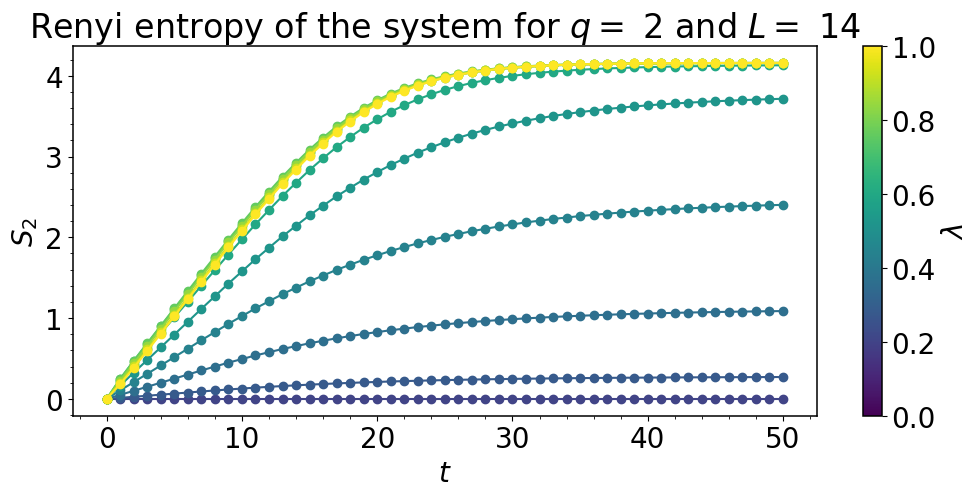

In [6]:
#Plot S2 as a function of time for different q and lambda. Compare with analytics.
l,k1,k2,r = 1,1,4,4
q=2
L = 14
T=50
lams = np.linspace(0,1,num=11)

#Computing S_2
rates = trans_rates(q)
Cs = finite_size_evolve(l,k1,k2,r,T,rates,L)
entropies = S2s(Cs,T,L,lams)

#Plotting the results
fig, ax = plt.subplots(figsize=matplotlib.figure.figaspect(0.4))
for i in range(len(entropies)):
    ax.plot(entropies[i],label=r'$\lambda = $'+str(np.round(lams[i],2)),c=cmap(0.2+0.8*lams[i]),marker='.',markersize=12)

    #Comparing with the exact analytical expression
    #a = q**(N/2)
    #d = 2*np.log(1-lams[i]**2)/np.log(q)
    #ax.plot(np.ones(len(entropies[-1]))*(-np.log((2*(a**2+a-1)-4*(a-1)*a**d+(a-1)*(a**2+2)*a**(2*d))/a**2/(a+1))),'k--')

plt.xlabel(r'$t$')
plt.ylabel(r'$S_2$')
sm = plt.cm.ScalarMappable(norm=plt.Normalize(vmin=0, vmax=1))
plt.colorbar(sm,ax=ax,label=r'$\lambda$')
ax.xaxis.set_minor_locator(matplotlib.ticker.MultipleLocator(2))
ax.yaxis.set_minor_locator(matplotlib.ticker.MultipleLocator(0.2))
plt.title(r'Renyi entropy of the system for $q = $ ' + str(q) + r' and $L = $ '+str(L))
plt.show()

/tmp/ipykernel_23414/1405031960.py:41: RuntimeWarning: divide by zero encountered in log
  plt.plot(lams2,np.minimum(np.ones(len(lams2))*np.log(q),-4*np.log(1-lams2**2))/2,'k--')
/tmp/ipykernel_23414/1405031960.py:68: RuntimeWarning: divide by zero encountered in log
  plt.plot(lams2,np.minimum(np.ones(len(lams2))*np.log(q),-4*np.log(1-lams2**2))/2/a_N_c[-1],'k--')


Text(0, 0.5, '$S_2/t$')

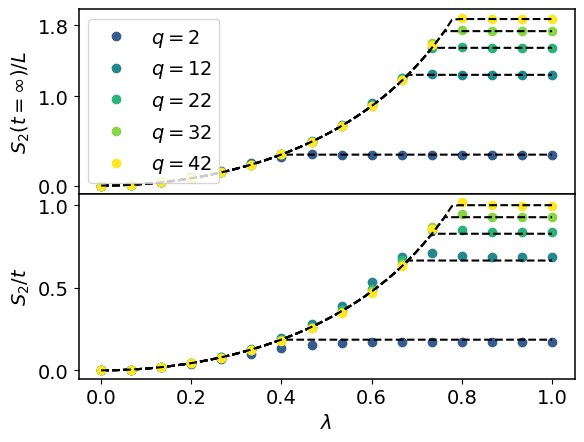

In [22]:
#Compute S2/L for large t, and compute S2/t in the regime where S2 ~ a*t + b
#Compare S2/L with analytical predictions, and compare S2/t with S2/L.

l,k1,k2,r = 1,1,4,4
q = 2
T = 50
lams = np.linspace(0,1,num=16)
lams2 = np.linspace(0,1,num=64) #this is the value used to plot analytical predictions. We want num large to have a smooth curve.

fig = plt.figure()
gs = fig.add_gridspec(2, hspace=0)
axs = gs.subplots(sharex=True)
axs[0].label_outer()
axs[1].label_outer()


plt.sca(axs[0])

#Fit S2 = a_L*L + b for t large and plot a_L as a function of lambda
#For each q, a_L(lam) is expected to saturate to some value a_L_c when lambda is too big.
Ls = [6,8,10,12]
qs = [2,12,22,32,42]

a_L_c = []
for q in qs:
    rates = trans_rates(q)

    #get the plateau value for S2 at large t.
    plats = np.zeros((len(Ls),len(lams)))
    for i in range(len(Ls)):
        L = Ls[i]
        Cs = finite_size_evolve(l,k1,k2,r,T,rates,L)
        entropies = S2s(Cs,T,L,lams)     
        plats[i,:] = entropies[:,T]
    
    #fit S2 = a*L + b and extract the slope from it
    slopes_L = np.array([sst.linregress(Ls,plats[:,j]).slope for j in range(len(lams))])
    a_L_c.append(slopes_L[-1])

    #plot a_L(lam) and compare it with the analytical prediction min(log(q),-4*log(1-lam**2))/2
    plt.plot(lams,slopes_L,'o',label=r'$q = $'+str(q),c=cmap(0.25+0.75*q/qs[-1]))
    plt.plot(lams2,np.minimum(np.ones(len(lams2))*np.log(q),-4*np.log(1-lams2**2))/2,'k--')
plt.legend()
plt.ylabel(r'$S_2(t=\infty)/L$')
plt.yticks([0,1,1.8])


#-------------------------------------------------------------------------------------------------------------------------


plt.sca(axs[1])

#Fit S2 = a_t*t + b (for t not too large) and plot a_t as a function of lambda.
#For each q, a_t(lam) is expected to saturate to some value a_t_c when lambda is too big.
L = 12
t_fit = np.arange(20) #time windows on which the linear regression is performed

a_t_c = []
for q in [2,12,22,32,42]:
    rates = trans_rates(q)
    Cs = finite_size_evolve(l,k1,k2,r,T,rates,L)
    entropies = S2s(Cs,T,L,lams)
    
    #fit S2 = a*t + b and extract the slope from it
    slopes_t = [sst.linregress(t_fit,entropies[j,:20]).slope for j in range(len(lams))]
    a_t_c.append(slopes_t[-1])

    #plot a_t(lam) and compare it with the same analytical prediction as for a_N, but rescaled.
    plt.plot(lams,slopes_t,'o',label=r'$q = $'+str(q),c=cmap(0.25+0.75*q/42))
    plt.plot(lams2,np.minimum(np.ones(len(lams2))*np.log(q),-4*np.log(1-lams2**2))/2/a_N_c[-1],'k--')
plt.xlabel(r'$\lambda$')
plt.ylabel(r'$S_2/t$')


## Computing the OTOC

For a given local operator $\mathcal{O}$, we want to compute $\mathbb{E}[\langle \mathcal{O} \mathcal{O}(t) \mathcal{O} \mathcal{O}(t) \rangle]$.

In practice, this corresponds to evolving $id \otimes ... id \otimes \mathcal{O_\text{loc}} \otimes id ... \otimes id$, and overlap it with $\text{SWAP} \otimes ... \text{SWAP} \otimes \mathcal{O_\text{loc}} \otimes \text{SWAP} ... \otimes \text{SWAP}$. In terms of the algorithm, this means evolving the algorithm with $l = r = 1$ and $k_1$, $k_2$ depending on $\mathcal{O}$, and overlapping it with $|4...4 \hspace{0.5mm} k_1 \hspace{0.5mm} k_2 \hspace{0.5mm} 4...4 \rangle$

We are interested in $\mathcal{O_\text{loc}} = |0 \rangle \langle 0|$, ie $k_1 = 0$ and $k_2 = 1$ in our basis.

Interestingly, the effect of SWAP on the basis is to exchange basis elements as follow: $1 \leftrightarrow 4$, $2 \leftrightarrow 5$, $3 \leftrightarrow 6$. This means that 
\begin{equation*}
\text{SWAP}(|1...1 \hspace{0.5mm} 0 \hspace{0.5mm} 1 \hspace{0.5mm} 1...1 \rangle) = |4...4 \hspace{0.5mm} 0 \hspace{0.5mm} 4 \hspace{0.5mm} 4...4 \rangle
\end{equation*}

So, by evolving $|1...1 \hspace{0.5mm} 0 \hspace{0.5mm} 1 \hspace{0.5mm} 1...1 \rangle$ for $t$ time steps, and performing a SWAP, we obtain the evolved state of $|4...4 \hspace{0.5mm} 0 \hspace{0.5mm} 4 \hspace{0.5mm} 4...4 \rangle$. Using this trick, we are able to compute $\mathbb{E}[\langle \mathcal{O} \mathcal{O}(t) \mathcal{O} \mathcal{O}(t) \rangle]$ for $2T$ steps by computing only $T$ steps.

The full algorithm is thus as follows:
- $\mathbb{E}[\langle \mathcal{O} \mathcal{O}(0) \mathcal{O} \mathcal{O}(0) \rangle] = 1/q$.
- For $T$ steps, we compute 
\begin{align*}
\mathbb{E}[\langle \mathcal{O} \mathcal{O}(t) \mathcal{O} \mathcal{O}(t) \rangle] = \langle \langle \text{SWAP}(\mathcal{O}(0))|\mathcal{O}(t) \rangle \rangle/q^N &= \frac{1}{q^N}\sum c_{i_1,...,i_{t+1}} \langle \langle 4...4 \hspace{0.5mm} 0 \hspace{0.5mm} 4 \hspace{0.5mm} 4...4|1 ... 1 \hspace{0.5mm} i_1 \hspace{0.5mm} i_1 \hspace{0.5mm} ... \hspace{0.5mm} i_{t+1} \hspace{0.5mm} i_{t+1} \hspace{0.5mm} 1 ... 1 \rangle \rangle\\
&= \frac{1}{q^{2t+2}} \sum c_{i_1,...,i_{t+1}} \langle \langle 4...4 \hspace{0.5mm} 0 \hspace{0.5mm} 4 \hspace{0.5mm} 4...4|\hspace{0.5mm} i_1 \hspace{0.5mm} i_1 \hspace{0.5mm} ... \hspace{0.5mm} i_{t+1} \hspace{0.5mm} i_{t+1} \hspace{0.5mm}\rangle \rangle\\
&= \frac{1}{q^{2t+2}} \sum c_{i_1,...,i_{t+1}} G_{4,i_1} G_{4,i_1}... G_{0,i_{\lfloor \frac{t+2}{2} \rfloor}} G_{4,i_{\lfloor \frac{t+3}{2} \rfloor}}... G_{4,i_{t+1}} G_{4,i_{t+1}}\\
\end{align*}

where $G_{i,j} = \langle \langle i | j \rangle \rangle$ are the Gram matrix coefficients. The last line indicates that the $t$ first $|i_k \rangle \rangle$ terms face $\langle \langle  4|$, the next one faces $\langle \langle  0|$, and the last $t+1$ terms face again $\langle \langle 4|$. This is computed efficiently using np.einsum().

- The last $T$ steps are obtained by computing 
\begin{equation*}\mathbb{E}[\langle \mathcal{O} \mathcal{O}(t+k) \mathcal{O} \mathcal{O}(t+k) \rangle] = \langle \langle \text{SWAP}(\mathcal{O}(k))|\mathcal{O}(T) \rangle \rangle/q^N = \mathbb{E}[\langle \mathcal{O} \mathcal{O}(T+k) \mathcal{O} \mathcal{O}(T+k) \rangle]
\end{equation*}
Here, the parities of $k$ and $T$ are important. Indeed, two rows in a brickwall circuits must have their operators non-aligned; if the first row has operators whose left legs corresponds to even sites, then the left legs of the other row's operators are on odd sites. Keeping this in mind [and maybe looking at the corresponding drawing], one realizes that $\langle \langle \text{SWAP}(\mathcal{O}(k))|$ has to be carefully positionned in front of $|\mathcal{O}(T) \rangle \rangle$. By drawing the whole circuit, we realize it means that either we evolve the system from $k_1 = 0$ and $k_2 = 4$, or from $k_1 = 4$ and $k_2 = 0$. However, these two evolutions give the same coefficients, so the only difference is a shift by one site in the position of the evolution cone. 

In [3]:
#compute the coefficients of the swapped version of the system.
#Input is C= an array with all coefficients of the systems for a particular time step.
#this corresponds to swapping 1 and 4, 2 and 5, 3 and 6 along all dimensions of C.
def swap_C(C):
    dim = len(C.shape)
    for i in range(dim):
        A = np.moveaxis(C,i,0).reshape(7,-1)
        A = A[[0,4,5,6,1,2,3],:]
        C = np.moveaxis(A.reshape([7]*dim),0,i)
    return C

#get the OTOC up to time 2T
def OTOC(Cs,T,q):
    G = Gram(q)
    otocs = [1/q]
    for t in range(T):
        otocs.append(np.einsum(*[Cs[t],np.arange(t+1)] + [elt for elt2 in [[G[:,4],[j//2]] for j in range(t)] for elt in elt2] +[G[:,0],[t//2]] + [elt for elt2 in [[G[:,4],[(j+t+1)//2]] for j in range(t+1)] for elt in elt2] ,optimize='greedy')/q**(2*t+2))
    for k in range(T):
        if k%2==T%2:
            otocs.append(np.einsum(*[Cs[T-1],np.arange(T)] +[swap_C(Cs[k]),np.arange(T,T+k+1)] + [elt for elt2 in [[G[:,4],[j//2]] for j in range(T-k-1)] for elt in elt2] +[elt for elt2 in [[G,[(T-k+j-1)//2,j//2+T]] for j in range(2*k+2)] for elt in elt2] + [elt for elt2 in [[G[:,4],[(T+j+k+1)//2]] for j in range(T-k-1)] for elt in elt2] ,optimize='greedy')/q**(2*T))
        if k%2==T%2:
            otocs.append(np.einsum(*[Cs[T-1],np.arange(T)] +[swap_C(Cs[k]),np.arange(T,T+k+1)] + [elt for elt2 in [[G[:,4],[j//2]] for j in range(T-k-2)] for elt in elt2] +[elt for elt2 in [[G,[(T-k+j-2)//2,j//2+T]] for j in range(2*k+2)] for elt in elt2] + [elt for elt2 in [[G[:,4],[(T+j+k)//2]] for j in range(T-k)] for elt in elt2] ,optimize='greedy')/q**(2*T))
    return(otocs)

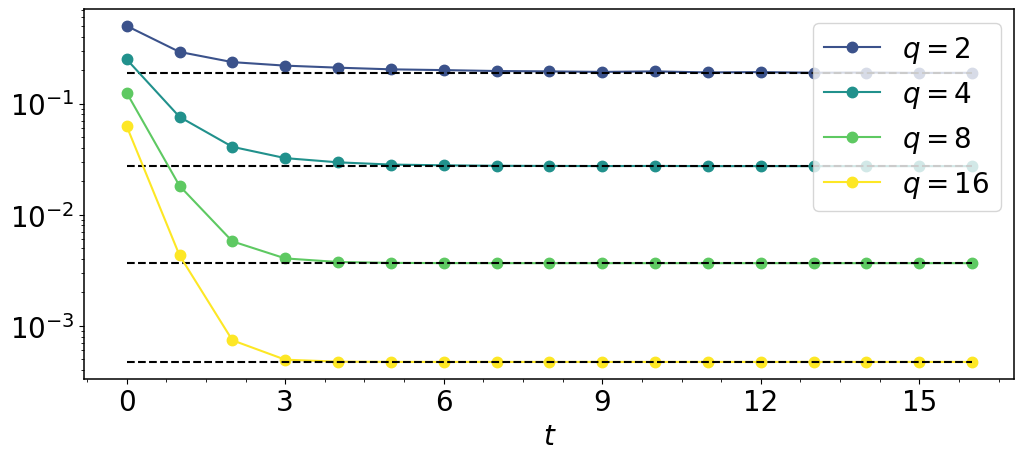

In [10]:
#plot the OTOC as a function of time, and compare it with the analytical prediction (2q-1)/q**4

l,k1,k2,r = 1,0,1,1
qs = [2,4,8,16]
T = 8

fig = plt.figure(figsize=matplotlib.figure.figaspect(0.4))

for q in qs:
    rates = trans_rates(q)

    Cs = C_evol(l,k1,k2,r,T,rates)
    otoc = OTOC(Cs,T,q)

    plt.semilogy(otoc,marker='.',markersize=15,label=r'$q = $'+str(q),c=cmap(np.log(q)/np.log(qs[-1])))
    plt.semilogy(np.ones(len(otoc))*(2*q-1)/q**4,'k--')

plt.xlabel(r'$t$')
plt.xticks([0,3,6,9,12,15])
plt.minorticks_on()
plt.legend(loc='upper right')